[Agent 4 Lesson](https://youtu.be/jGg_1h0qzaM?t=9083) - Human in the loop

Need to look at injected state - outside the scope of the training

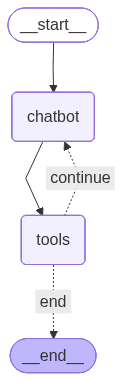

In [17]:
from typing import Annotated, Sequence, TypedDict

from IPython.display import Image, display
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

document_content=""  # Used as a workaround instead of injection

class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    

@tool
def update(content: str) -> str:
    """ Update function which updates the document content with the provided content """
    global document_content
    document_content = content
    return f"Update tool called. Current length: {len(document_content)}"
    

@tool
def save(filename: str) -> str:
    """ Save function which saves the current document content to a file 

        Args:
            filename (str): The name of the markdown file to save the document content to
    """
    global document_content
    try:
        with open(filename, "w") as f:
            f.write(document_content)
        return f"Document content saved to {filename}"
    except Exception as e:
        return f"Failed to save document content: {e}"
    

tools = [update, save]    
ollama = ChatOllama(model="llama3.1:8b", host="http://localhost:11434").bind_tools(tools)


def chat_node(state: State) -> State:
    system_message = SystemMessage(content=f"""
        You are a Drafter, a helpful writing assistant. 
        You are going to help the user draft a document. 
        You have access to the following tools:
        - update(content: str): Update the document content with the new content.
        - save(filename: str): Save the current document content to a file if the user wants to save the document. The filename should end with .md as the document will be saved in markdown format
        Make sure to always show the current document state after modifications.
                                   
        The current document content is: {document_content}
    """)

    user_input = input("what would you like to do? (update/save): ")
    user_message = HumanMessage(content=user_input)

    chatbot_messages = [system_message] + state["messages"] + [user_message]
    print("*** LLM call:", chatbot_messages)
    response = ollama.invoke(chatbot_messages)
    print(f"AI: {response.content}")
    if (hasattr(response, "tool_calls") and response.tool_calls):
        print("*** Tool calls:", response.tool_calls)
    
    # We only return the NEW messages. The add_messages reducer 
    # in our State definition will automatically append them to history.
    return { "messages": [user_message, response] }


def should_continue(state: State) -> str:
    messages = state["messages"]
    if not messages:
        return "continue"
    for message in reversed(messages):
        if (isinstance(message, ToolMessage) and 
            "saved" in message.content.lower() and
            "document" in message.content.lower()):
            return "end"
    return "continue"

graph = StateGraph(State)
graph.add_node("tools", ToolNode(tools=tools))
graph.add_node("chatbot", chat_node)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", "tools")
graph.add_conditional_edges(
    "tools", 
    should_continue, 
    {
        "continue": "chatbot", 
        "end": END
    }
)

worflow = graph.compile()
display(Image(worflow.get_graph().draw_mermaid_png()))

In [18]:
state = {"messages": []}
# result = worflow.invoke(state)
# print(result["messages"][-1].content) # [-1] gets the last item in the list

result = worflow.stream(state, stream_mode="values")
for s in result:
    if "messages" in s and len(s["messages"]) > 0:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print('tuple message')
            print(message)
        else:
            message.pretty_print()


*** LLM call: [SystemMessage(content='\n        You are a Drafter, a helpful writing assistant. \n        You are going to help the user draft a document. \n        You have access to the following tools:\n        - update(content: str): Update the document content with the new content.\n        - save(filename: str): Save the current document content to a file if the user wants to save the document. The filename should end with .md as the document will be saved in markdown format\n        Make sure to always show the current document state after modifications.\n\n        The current document content is: \n    ', additional_kwargs={}, response_metadata={}), HumanMessage(content='create email to say I will not be going to work tomorrow', additional_kwargs={}, response_metadata={})]
AI: 
*** Tool calls: [{'name': 'update', 'args': {'content': 'Cutting Knowledge Date: December 2023\n\nI wanted to let you know that unfortunately, I will be unable to come into work tomorrow. I apologize for